# NTU RGB+D 60: treino de um baseline em skeleton 3D

Este notebook é autocontido: ele baixa as anotações pré-processadas, inspeciona o dataset, seleciona um subconjunto de classes, prepara os dados, treina um modelo leve e exporta os artefatos finais.

A ideia é validar rapidamente o pipeline com skeleton 3D antes de partir para modelos mais pesados.

In [1]:
%%capture
%pip install torch torchvision torchaudio numpy pandas scikit-learn matplotlib tqdm jupyter requests tqdm

## Instalação das dependências

Esta célula instala as bibliotecas usadas ao longo do notebook. Ela garante que o ambiente tenha suporte para download, manipulação de dados, treino em PyTorch, métricas e visualização.

In [2]:
from pathlib import Path
from typing import Final

import requests
from tqdm.notebook import tqdm

DATA_DIR: Path = Path("data/nturgbd")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ANNOTATION_URL: str = "https://download.openmmlab.com/mmaction/pyskl/data/nturgbd/ntu60_3danno.pkl"
ANNOTATION_PATH: Path = DATA_DIR / "ntu60_3danno.pkl"
MAX_DOWNLOAD_ATTEMPTS: Final[int] = 5
REQUEST_TIMEOUT: Final[tuple[float, float]] = (10.0, 60.0)
BLOCK_SIZE: Final[int] = 1024 * 1024


def download_file_notebook(
    url: str,
    destination_path: Path,
    *,
    max_attempts: int = MAX_DOWNLOAD_ATTEMPTS,
    block_size: int = BLOCK_SIZE,
    timeout: tuple[float, float] = REQUEST_TIMEOUT,
) -> None:
    """Download a file in a notebook with automatic retry and resume support.

    Args:
        url: File URL to download.
        destination_path: Local path where the file will be stored.
        max_attempts: Maximum number of download attempts.
        block_size: Chunk size used while streaming the response body.
        timeout: Connection and read timeout passed to ``requests.get``.

    Raises:
        RuntimeError: If the download fails after all retry attempts.
        requests.RequestException: Re-raised after the final failed attempt.
    """
    destination_path.parent.mkdir(parents=True, exist_ok=True)

    last_error: Exception | None = None

    for attempt in range(1, max_attempts + 1):
        existing_bytes: int = destination_path.stat().st_size if destination_path.exists() else 0
        headers: dict[str, str] = {}
        if existing_bytes > 0:
            headers["Range"] = f"bytes={existing_bytes}-"

        try:
            with requests.get(url, stream=True, headers=headers, timeout=timeout) as response:
                response.raise_for_status()

                total_size: int | None = None
                content_range: str | None = response.headers.get("Content-Range")
                if content_range and "/" in content_range:
                    remote_total_str: str = content_range.rsplit("/", 1)[1].strip()
                    if remote_total_str.isdigit():
                        total_size = int(remote_total_str)
                else:
                    content_length_header: str | None = response.headers.get("content-length")
                    if content_length_header is not None:
                        content_length: int = int(content_length_header)
                        total_size = existing_bytes + content_length if response.status_code == 206 else content_length

                if existing_bytes > 0 and response.status_code == 200:
                    print("ℹ️ O servidor não aceitou a retomada parcial; recomeçando do zero.")
                    existing_bytes = 0

                file_mode: str = "ab" if existing_bytes > 0 and response.status_code == 206 else "wb"
                progress_initial: int = existing_bytes if file_mode == "ab" else 0

                with tqdm(
                    total=total_size,
                    initial=progress_initial,
                    unit="iB",
                    unit_scale=True,
                    desc=destination_path.name,
                ) as progress_bar, open(destination_path, file_mode) as file:
                    for chunk in response.iter_content(chunk_size=block_size):
                        if chunk:
                            file.write(chunk)
                            progress_bar.update(len(chunk))

            print(f"✅ Download concluído: {destination_path}")
            return

        except (requests.RequestException, OSError) as exc:
            last_error = exc
            is_last_attempt: bool = attempt == max_attempts
            if is_last_attempt:
                break

            wait_seconds: int = min(2 ** (attempt - 1), 30)
            print(
                f"⚠️ Tentativa {attempt}/{max_attempts} falhou para {destination_path.name}: {exc}"
                f". Tentando novamente em {wait_seconds}s..."
            )
            import time

            time.sleep(wait_seconds)

    raise RuntimeError(
        f"Falha ao baixar {url!r} para {destination_path} após {max_attempts} tentativas."
    ) from last_error


if not ANNOTATION_PATH.exists():
    download_file_notebook(ANNOTATION_URL, ANNOTATION_PATH)

print(f"Annotation file ready at: {ANNOTATION_PATH}")

Annotation file ready at: data\nturgbd\ntu60_3danno.pkl


## Download das anotações

Aqui definimos o diretório local, a URL do arquivo pré-processado e uma função de download com retry e retomada parcial. O objetivo é tornar a preparação dos dados mais robusta dentro do notebook.

## Explorando as classes do NTU RGB+D

A célula abaixo resume as classes disponíveis no dataset, mostra a distribuição de amostras por classe e exibe um gráfico para facilitar a leitura da frequência de cada rótulo.

Dataset keys: ['split', 'annotations']
Split keys: ['xsub_train', 'xsub_val', 'xset_train', 'xset_val', 'xview_train', 'xview_val']
Total annotations: 56,578
Unique classes: 60
Smallest class size: 906
Largest class size: 948


class_id,samples,percentage
0,940,1.66%
1,941,1.66%
2,938,1.66%
3,940,1.66%
4,942,1.66%
5,943,1.67%
6,944,1.67%
7,941,1.66%
8,936,1.65%
9,941,1.66%


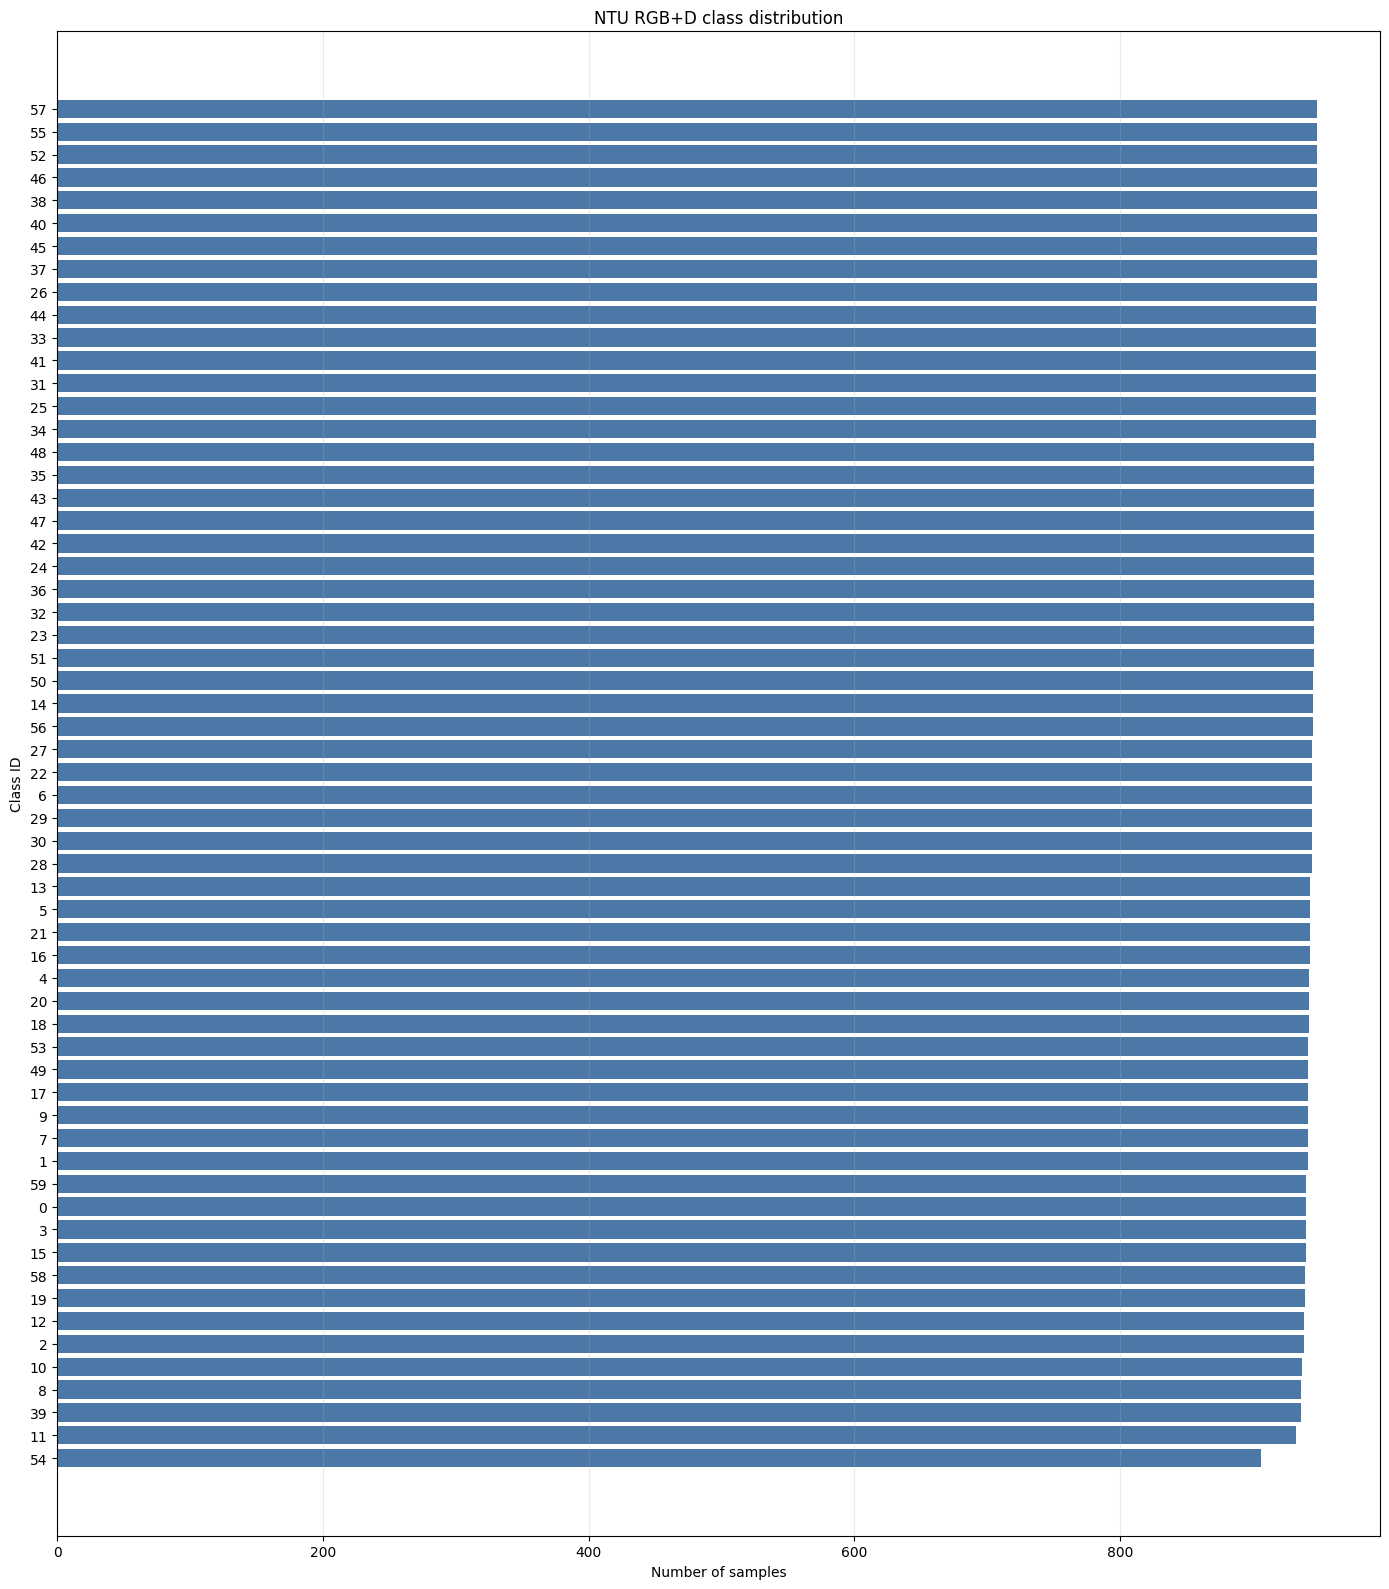

Preview of the first annotations:


,frame_dir,label,keypoint,total_frames
0,S001C001P001R001A001,0,"[[[[0.2181 0.1726 3.785 ], [0.2323 0.4326 3.71...",103
1,S001C001P001R001A002,1,"[[[[0.2627 0.1947 3.828 ], [0.2761 0.451 3.75...",158
2,S001C001P001R001A003,2,"[[[[0.1666 0.1693 3.764 ], [0.1821 0.43 3.69...",104
3,S001C001P001R001A004,3,"[[[[0.1952 0.1962 3.818 ], [0.2083 0.4492 3.73...",99
4,S001C001P001R001A005,4,"[[[[0.2162 0.1857 3.768 ], [0.2285 0.4375 3.69...",54
5,S001C001P001R001A006,5,"[[[[0.1918 0.1897 3.762 ], [0.2065 0.437 3.68...",75
6,S001C001P001R001A007,6,"[[[[0.2377 0.235 3.746 ], [0.247 0.469 3.67 ]...",86
7,S001C001P001R001A008,7,"[[[[-0.08014 0.1351 3.691 ], [-0.0585 0.3...",71
8,S001C001P001R001A009,8,"[[[[ 0.2241 -0.03198 4.023 ], [0.217 0.177...",67
9,S001C001P001R001A010,9,"[[[[-0.03537 0.1924 3.682 ], [-0.02104 0....",69


In [3]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pkl_path = Path("data/nturgbd/ntu60_3danno.pkl")
with open(pkl_path, "rb") as f:
    data = pickle.load(f)

annotations_df = pd.DataFrame(data["annotations"])
class_distribution_df = (
    annotations_df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("class_id")
    .reset_index(name="samples")
)
class_distribution_df["percentage"] = (
    class_distribution_df["samples"] / class_distribution_df["samples"].sum() * 100.0
)

print(f"Dataset keys: {list(data.keys())}")
print(f"Split keys: {list(data['split'].keys())}")
print(f"Total annotations: {len(annotations_df):,}")
print(f"Unique classes: {class_distribution_df['class_id'].nunique()}")
print(f"Smallest class size: {class_distribution_df['samples'].min()}")
print(f"Largest class size: {class_distribution_df['samples'].max()}")

display(
    class_distribution_df.style.format({"percentage": "{:.2f}%"}).hide(axis="index")
)

fig, ax = plt.subplots(figsize=(14, 16))
plot_df = class_distribution_df.sort_values("samples", ascending=True)
ax.barh(plot_df["class_id"].astype(str), plot_df["samples"], color="#4C78A8")
ax.set_title("NTU RGB+D class distribution")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Class ID")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

print("Preview of the first annotations:")
display(annotations_df.head(10))

## Inspeção inicial do dataset

Esta etapa carrega o arquivo `.pkl`, transforma as anotações em uma tabela e resume a distribuição das classes. Isso ajuda a confirmar que o arquivo foi lido corretamente e a entender o equilíbrio do dataset antes de filtrar qualquer subconjunto.

In [4]:
POSITIVE_CLASSES = {
    34: "bow",                 # A35
    36: "wipe_face",           # A37
    40: "sneeze",              # A41
    43: "touch_head",          # A44
    44: "touch_chest",         # A45
    46: "touch_neck",          # A47
    47: "nausea_vomiting",     # A48
}

NEUTRAL_CLASSES = {
    10: "reading",             # A11
    11: "writing",             # A12
    17: "wear_glasses",        # A18
    18: "take_off_glasses",    # A19
    27: "phone_call",          # A28
    29: "typing",              # A30
    32: "check_time",          # A33    
}


SELECTED_CLASSES = {**NEUTRAL_CLASSES, **POSITIVE_CLASSES}

label_to_new = {old_label: i for i, old_label in enumerate(SELECTED_CLASSES.keys())}
id_to_name = {i: name for i, name in enumerate(SELECTED_CLASSES.values())}
print(label_to_new)
print(id_to_name)

{10: 0, 11: 1, 17: 2, 18: 3, 27: 4, 29: 5, 32: 6, 34: 7, 36: 8, 40: 9, 43: 10, 44: 11, 46: 12, 47: 13}
{0: 'reading', 1: 'writing', 2: 'wear_glasses', 3: 'take_off_glasses', 4: 'phone_call', 5: 'typing', 6: 'check_time', 7: 'bow', 8: 'wipe_face', 9: 'sneeze', 10: 'touch_head', 11: 'touch_chest', 12: 'touch_neck', 13: 'nausea_vomiting'}


## Seleção e remapeamento das classes

Aqui escolhemos um subconjunto de ações mais útil para o problema e remapeamos os rótulos para uma faixa contínua começando em zero. Isso simplifica o treino do classificador e mantém o experimento focado.

In [5]:
selected_annotations = [
    ann for ann in data["annotations"]
    if ann["label"] in SELECTED_CLASSES
]
for ann in selected_annotations:
    ann["orig_label"] = ann["label"]
    ann["label"] = label_to_new[ann["label"]]
print("total subset:", len(selected_annotations))

total subset: 13214


## Filtragem do subconjunto escolhido

Depois de definir as classes de interesse, esta célula mantém apenas as anotações correspondentes e guarda o rótulo original para referência futura.

In [6]:
available_splits = list(data["split"].keys())
print("splits:", available_splits)

splits: ['xsub_train', 'xsub_val', 'xset_train', 'xset_val', 'xview_train', 'xview_val']


## Verificação dos splits disponíveis

Antes de separar treino e validação, esta célula mostra quais divisões já existem no arquivo. Assim evitamos assumir nomes de split que não estejam presentes no `.pkl`.

In [7]:
train_ids = set(data["split"]["xsub_train"])
val_ids   = set(data["split"]["xsub_val"])
print("train ids:", len(train_ids))
print("val ids:", len(val_ids))

train ids: 40091
val ids: 16487


## Definição do split de treino e validação

Aqui selecionamos os identificadores usados no split cross-subject. Esse tipo de divisão é útil porque testa a capacidade do modelo de generalizar para pessoas que não apareceram no treino.

In [8]:
train_annotations = [a for a in selected_annotations if a["frame_dir"] in train_ids]
val_annotations   = [a for a in selected_annotations if a["frame_dir"] in val_ids]

print(len(train_annotations), len(val_annotations))

9365 3849


## Pré-processamento do skeleton

Nesta parte transformamos o skeleton variável em uma representação fixa: escolhemos a pessoa principal, centralizamos a pose, reamostramos o tempo e criamos um vetor com posição e velocidade. Isso deixa os dados prontos para um modelo sequencial leve.

In [9]:
import numpy as np

TARGET_FRAMES = 64

def select_main_person(kp):
    # kp shape: [M, T, V, C]
    # escolhe a pessoa com maior energia de movimento
    energies = []
    for m in range(kp.shape[0]):
        person = kp[m]
        energy = np.nan_to_num(np.abs(np.diff(person, axis=0))).sum()
        energies.append(energy)
    main_idx = int(np.argmax(energies))
    return kp[main_idx]  # [T, V, C]

def center_on_root(person_kp, root_idx=1):
    # root_idx ajustar depois de inspecionar o esqueleto; a ideia é centralizar numa junta do tronco
    root = person_kp[:, root_idx:root_idx+1, :]
    return person_kp - root

def temporal_resample(person_kp, target_frames=64):
    T = person_kp.shape[0]
    if T == target_frames:
        return person_kp
    idx = np.linspace(0, T - 1, target_frames).astype(np.int32)
    return person_kp[idx]

def build_feature(person_kp):
    # [T, V, C] -> [T, V*C]
    pos = person_kp.reshape(person_kp.shape[0], -1)
    vel = np.diff(pos, axis=0, prepend=pos[:1])
    feat = np.concatenate([pos, vel], axis=-1)  # leve e útil
    return feat.astype(np.float32)

def preprocess_ann(ann):
    kp = ann["keypoint"]               # [M, T, V, C]
    person = select_main_person(kp)
    person = center_on_root(person)
    person = temporal_resample(person, TARGET_FRAMES)
    feat = build_feature(person)       # [T, 2*V*C]
    label = ann["label"]
    return feat, label

## Dataset e DataLoader

Aqui encapsulamos o pré-processamento em um `Dataset` do PyTorch e criamos os `DataLoader`s de treino e validação. Isso padroniza o acesso aos dados e facilita o treinamento em mini-batches.

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

class NTUSubsetDataset(Dataset):
    def __init__(self, annotations):
        self.items = [preprocess_ann(a) for a in annotations]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        x, y = self.items[idx]
        return torch.tensor(x), torch.tensor(y)

train_ds = NTUSubsetDataset(train_annotations)
val_ds = NTUSubsetDataset(val_annotations)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

xb, yb = next(iter(train_dl))
print(xb.shape, yb.shape)

torch.Size([64, 64, 150]) torch.Size([64])


## Modelo baseline

Esta célula define um BiGRU pequeno como baseline. Ele é simples, rápido de treinar e suficiente para validar se o pipeline de dados está funcionando antes de partir para arquiteturas mais sofisticadas.

In [11]:
import torch.nn as nn

NUM_CLASSES = len(SELECTED_CLASSES)

class TinyBiGRU(nn.Module):
    def __init__(self, input_dim=150, hidden_dim=128, num_layers=2, num_classes=8, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        pooled = out.mean(dim=1)
        return self.head(pooled)

model = TinyBiGRU(num_classes=NUM_CLASSES)
print(sum(p.numel() for p in model.parameters()) / 1e6, "M params")

0.546702 M params


## Configuração do treino

Aqui escolhemos o dispositivo de execução, movemos o modelo para ele e definimos a função de perda e o otimizador. Essa configuração prepara o ambiente para o loop de treinamento.

In [12]:
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
print("Training setup complete. Ready to train the model.")

Using device: cpu
Training setup complete. Ready to train the model.


## Loop de treino e validação

Esta célula executa o ciclo completo de treino por época, calcula métricas e salva o melhor checkpoint. O objetivo é acompanhar o desempenho do modelo de forma simples e reprodutível.

In [13]:
from sklearn.metrics import f1_score, accuracy_score
from tqdm.notebook import tqdm
import numpy as np

def run_epoch(model, dl, train=True):
    model.train(train)
    losses = []
    y_true, y_pred = [], []

    for xb, yb in tqdm(dl):
        xb, yb = xb.to(device), yb.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optimizer.step()

        losses.append(loss.item())
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds)

    return {
        "loss": float(np.mean(losses)),
        "acc": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro")
    }

# If not exists, create the artifacts directory to save the best model
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

best_f1 = -1
for epoch in range(1, 21):
    train_metrics = run_epoch(model, train_dl, train=True)
    val_metrics = run_epoch(model, val_dl, train=False)

    print(f"Epoch {epoch}")
    print("train:", train_metrics)
    print("val  :", val_metrics)

    if val_metrics["f1_macro"] > best_f1:
        best_f1 = val_metrics["f1_macro"]
        torch.save(model.state_dict(), artifacts_dir / "tiny_bigru_ntu60_subset.pt")

  0%|          | 0/147 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

Epoch 1
train: {'loss': 2.1446032637641546, 'acc': 0.27463961558996264, 'f1_macro': 0.26595740262479534}
val  : {'loss': 1.7246730151723644, 'acc': 0.4177708495713172, 'f1_macro': 0.3923804047400531}


  0%|          | 0/147 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

...

  0%|          | 0/61 [00:00<?, ?it/s]

Epoch 19
train: {'loss': 0.3795674424998614, 'acc': 0.8569140416444208, 'f1_macro': 0.8565398809037872}
val  : {'loss': 0.9359845753575935, 'acc': 0.7259028319043908, 'f1_macro': 0.7233014354000993}


  0%|          | 0/147 [00:00<?, ?it/s]

  0%|          | 0/61 [00:00<?, ?it/s]

Epoch 20
train: {'loss': 0.34643062837675315, 'acc': 0.8712226374799786, 'f1_macro': 0.8709048279332876}
val  : {'loss': 0.9730537343220632, 'acc': 0.7391530267601975, 'f1_macro': 0.7363568888789199}


## Avaliação final

Depois do treino, esta célula gera relatório de classificação e matriz de confusão. Isso ajuda a identificar quais classes o modelo confunde com mais frequência e onde o baseline ainda precisa melhorar.

                  precision    recall  f1-score   support

         reading       0.62      0.47      0.53       273
         writing       0.51      0.44      0.48       272
    wear_glasses       0.86      0.79      0.82       273
take_off_glasses       0.83      0.86      0.85       274
      phone_call       0.83      0.78      0.80       275
          typing       0.61      0.70      0.65       275
      check_time       0.83      0.81      0.82       276
             bow       0.93      0.93      0.93       276
       wipe_face       0.70      0.78      0.74       276
          sneeze       0.80      0.62      0.70       276
      touch_head       0.60      0.76      0.67       276
     touch_chest       0.72      0.92      0.80       276
      touch_neck       0.68      0.67      0.67       276
 nausea_vomiting       0.85      0.83      0.84       275

        accuracy                           0.74      3849
       macro avg       0.74      0.74      0.74      3849
    weighted

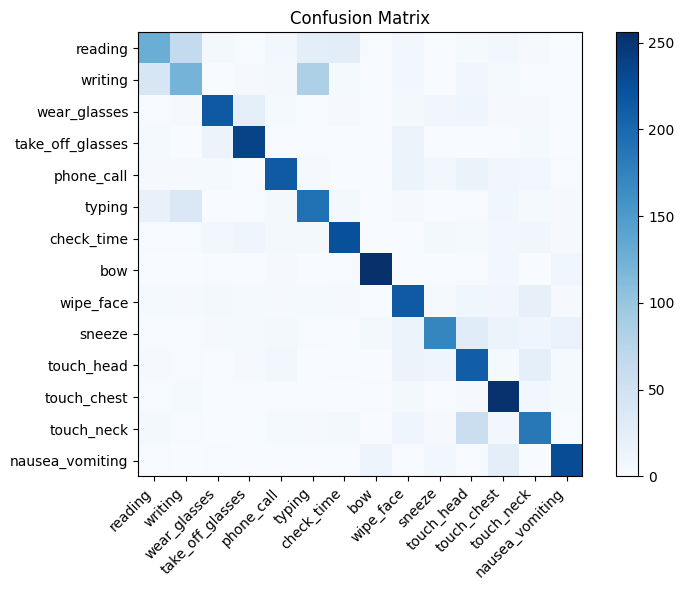

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

def predict_all(model, dl):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = predict_all(model, val_dl)
print(classification_report(y_true, y_pred, target_names=[id_to_name[i] for i in range(NUM_CLASSES)]))
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(NUM_CLASSES), [id_to_name[i] for i in range(NUM_CLASSES)], rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), [id_to_name[i] for i in range(NUM_CLASSES)])
plt.title("Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

## Exportação dos artefatos

Por fim, salvamos os nomes das classes e a configuração usada no experimento. Esses arquivos permitem reutilizar o mesmo mapeamento de rótulos em inferência, análise ou etapas futuras do projeto.

In [16]:
import json
with open("artifacts/id_to_name.json", "w") as f:
    json.dump(id_to_name, f, indent=2)

with open("artifacts/config.json", "w") as f:
    json.dump({
        "target_frames": TARGET_FRAMES,
        "selected_classes": SELECTED_CLASSES,
        "label_to_new": label_to_new
    }, f, indent=2)